# Demo Video — FSCG Presentation

Renders a polished 1.CFL clip with pitch-line homography overlay, team-coloured
tracked players, jersey names, live speed and distance, and a minimap. Designed
as a pitch artefact for the FSCG presentation, not a fully unsupervised pipeline.

## Workflow

1. **Configure** — pick the match, start timestamp, clip length, and player names.
2. **Render** — produce the demo MP4 with the current pipeline.
3. **Label** — scrub through the rendered MP4 and tag bad-homography frames.
4. **Calibrate** — for the worst frames, click pitch landmarks to lock in a
   ground-truth homography.
5. **Compare** — see the current pipeline vs ground truth side by side, with
   per-frame pixel error. Calibrated frames also feed back into the next render
   as runtime seeds.

Steps 3-5 form an iteration loop: more calibrated frames → better evaluation →
better diagnosis → re-run step 2.

In [9]:
import sys, importlib, cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Force reloads — the kernel caches modules across edits, which silently
# masks src/* changes until the next restart otherwise.
import src.run_pnlcalib_video as R; importlib.reload(R)
import src.run_demo as D; importlib.reload(D)

from src.config import Config
from src.camera_motion import CameraMotionTracker
from src.manual_calibration import load_match_seeds
from src.run_pnlcalib_video import (
    load_models, predict_one_frame, project_lines,
    ProjectionSmoother, refine_projection_to_lines, REFINE_STATS,
    check_projection_sanity, check_line_alignment,
)


## 1 · Configuration

Pick the match, where in the video to start, and how long the clip should be.
Pre-roll runs the tracker silently before the rendered window so player IDs and
speed/distance are warm by frame 1.

In [10]:
MATCH               = 'sut-mla'
START_TS            = '1:04:48'   # absolute video timestamp (HH:MM:SS)
DURATION_SEC        = 18
PREROLL_SEC         = 15          # tracker warm-up before START_TS
DEVICE              = 'cuda:0'

BALL_CONF_THRESHOLD = 0.08        # below YOLO default — catch more ball detections
BALL_MAX_GAP        = 20          # frames to extrapolate a missed ball (~0.8s @ 25fps)


## 2 · Load models — run once per session

In [11]:
yolo       = YOLO(Config.resolve_yolo_model())
pnl_models = load_models(DEVICE)
print('Models ready.')


Models ready.


## 3 · Player names + ID remaps

`PLAYER_NAMES` maps a BoT-SORT track ID to `(display_name, team_id, jersey_no)`.
Multiple track IDs can map to the same player — happens when a player exits the
frame and re-enters with a fresh ID.

- `team_id`: 0 = Sutjeska (blue) · 1 = Mladost (yellow) · 2 = Other (ref/staff)
- `jersey_no`: integer, or `None` to omit

`TRACK_REMAPS` patches in mid-clip ID swaps — when two players cross and BoT-SORT
swaps their IDs, list the swap as `(seconds_into_render, {old_id: new_id, ...})`.

In [12]:
PLAYER_NAMES: dict[int, tuple[str, int, int | None]] = {
    # ── SUTJESKA ─────────────────────────────────────────────────────────────
    # Defence
    289: ('A.Babic',       0,  72),  513: ('A.Babic',       0,  72),
    319: ('B. Kopitovic',  0,  15),  519: ('B. Kopitovic',  0,  15),
    106: ('A. Golubovic',  0,   2),  611: ('A. Golubovic',  0,   2),
    339: ('M. Vracar',     0,   4),  653: ('M. Vracar',     0,   4),
    # Midfield
    397: ('D. Hocko',      0,  44),
    382: ('J. Cadjenovic', 0,  20),
    596: ('V. Kalezic',    0,  70),  419: ('V. Kalezic',    0,  70),
    # Attack
    415: ('I. Vukcevic',   0,   7),  656: ('I. Vukcevic',   0,   7),
    535: ('M. Jukovic',    0,  88),  395: ('M. Jukovic',    0,  88),
    428: ('V. Cavor',      0,  24),  621: ('V. Cavor',      0,  24),

    # ── MLADOST ──────────────────────────────────────────────────────────────
    # Goalkeeper
    675: ('B.Radanovic',   1,  31),  716: ('B.Radanovic',   1,  31),
    # Defence
    439: ('M.Badnjar',     1,   3),  651: ('M.Badnjar',     1,   3),
    638: ('Z.Ceklic',      1,   6),  437: ('Z.Ceklic',      1,   6),
    429: ('J.Vujisic',     1,   5),  605: ('J.Vujisic',     1,   5),
    412: ('V.Vickovic',    1,  18),  544: ('V.Vickovic',    1,  18),
    # Midfield
    394: ('D.Kontic',      1,   8),
    392: ('N.Radusinovic', 1,  16),
    389: ('D.Vukovic',     1,  77),
    # Attack
    266: ('J.Roganovic',   1,  29),
    253: ('N.A.Cordoba',   1,  28),
    230: ('L.Knezevic',    1,   7),  604: ('L.Knezevic',    1,   7),

    # ── REFEREES ─────────────────────────────────────────────────────────────
    337: ('Sudija', 2, None),  393: ('Sudija', 2, None),
    502: ('Sudija', 2, None),  494: ('Sudija', 2, None),
}

TRACK_REMAPS: list[tuple[float, dict[int, int]]] = [
    # At second 14 of the rendered window: Cordoba and Vracar's IDs swap.
    # raw 253 → display as Cordoba (339);  raw 653 → display as Vracar (253).
    (14, {253: 339, 653: 253}),
]


## 4 · Render the demo MP4

Each frame goes through:

- YOLO detection + BoT-SORT tracking (`persist=True`)
- Wide-shot gate — homography is skipped on close-ups so the flow tracker
  doesn't re-seed on a useless view
- PnLCalib → optical-flow propagation (gated on `check_projection_sanity` +
  `check_line_alignment`) → manual seed fallback → stale-hold from the smoother
- `refine_projection_to_lines` snaps the candidate P onto painted white pixels
- `ProjectionSmoother` EMA-blends across frames
- Per-player foot is projected to pitch coords for the speed/distance tracker
  (which accumulates through pre-roll so stats are warm by render frame 0)
- Render: white pitch lines, team-coloured ellipses + name badges, ball triangle,
  minimap, video-timestamp

Output: `output/demo/{slug}_{ts}_demo.mp4`. The summary at the bottom prints
homography source attribution, ball detection vs extrapolation count, and refine
stats so you can see at a glance what's working.

In [13]:
# ── Setup ───────────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(str(Config.MATCH_VIDEOS[MATCH]))
fps = cap.get(cv2.CAP_PROP_FPS)
fw  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
fhv = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

start_abs      = int(D.parse_ts(START_TS) * fps)
preroll_frames = int(PREROLL_SEC * fps)
render_frames  = int(DURATION_SEC * fps)
clip_start     = max(0, start_abs - preroll_frames)

ts_safe  = START_TS.replace(':', '-')
out_path = str(Config.OUTPUT_DIR / 'demo' / f'{MATCH}_{ts_safe}_demo.mp4')
Path(out_path).parent.mkdir(parents=True, exist_ok=True)
writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (fw, fhv))

# Reset BoT-SORT counter so track IDs are reproducible run-to-run.
if hasattr(yolo, 'predictor') and yolo.predictor is not None:
    yolo.predictor = None
from ultralytics.trackers.basetrack import BaseTrack
BaseTrack._count = 0

# Homography stack
smoother       = ProjectionSmoother(alpha=0.3, max_stale_frames=int(fps * 3))
motion_tracker = CameraMotionTracker()
manual_seeds   = load_match_seeds(MATCH)
print(f'Manual seeds for {MATCH}: {len(manual_seeds)}')

# Per-player speed / distance
player_stats = D.PlayerStats(fps)

# Ball history (last 2 frames) for velocity-based extrapolation across gaps
_ball_bboxes, _ball_frames, _ball_pitch = [], [], []

# Stats
homog_stats = {k: 0 for k in (
    'pnlcalib', 'flow', 'flow_rejected', 'manual_seed', 'stale', 'none',
    'close_up', 'inference_fail', 'sanity_fail', 'line_fail',
)}
ball_hits = 0
ball_carry = 0
for _k in list(REFINE_STATS):
    REFINE_STATS[_k] = 0


# ── Render loop ─────────────────────────────────────────────────────────────
cap.set(cv2.CAP_PROP_POS_FRAMES, clip_start)

for frame_i in tqdm(range(preroll_frames + render_frames), desc='Render'):
    ret, frame = cap.read()
    if not ret:
        break

    is_render  = frame_i >= preroll_frames
    abs_frame  = clip_start + frame_i
    render_sec = (frame_i - preroll_frames) / fps

    # Detect + track
    boxes = yolo.track(
        frame, imgsz=1280,
        conf=min(Config.PLAYER_CONF_THRESHOLD, BALL_CONF_THRESHOLD),
        tracker=f'{Config.TRACKER_TYPE}.yaml',
        persist=True, verbose=False,
    )[0].boxes

    players = []
    best_ball_bbox, best_ball_conf = None, -1
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i])
        bbox   = boxes.xyxy[i].cpu().numpy().astype(int).tolist()
        conf   = float(boxes.conf[i])
        tid    = int(boxes.id[i]) if boxes.id is not None else -1
        if cls_id == 0 and conf >= Config.PLAYER_CONF_THRESHOLD:
            players.append({'bbox': bbox, 'conf': conf, 'track_id': tid})
        elif cls_id == 1 and conf >= BALL_CONF_THRESHOLD and conf > best_ball_conf:
            best_ball_bbox, best_ball_conf = bbox, conf

    wide = D.is_wide_shot(players, fhv)

    # Homography (only on wide frames; close-ups reset the flow trail)
    P_smooth = None
    if wide:
        P_raw, status = predict_one_frame(
            frame, pnl_models, fw, fhv,
            manual_seeds=manual_seeds, abs_frame=abs_frame,
        )
        tag = status

        if P_raw is not None:
            motion_tracker.seed(frame, P_raw)
        else:
            P_flow = motion_tracker.propagate(frame)
            if P_flow is not None:
                # Gate flow on the same checks main() uses: if it's drifted,
                # drop it so we go stale instead of painting wrong lines.
                player_boxes = [p['bbox'] for p in players]
                if (check_projection_sanity(P_flow, player_boxes)
                        and check_line_alignment(P_flow, frame, min_score=0.12)):
                    P_raw, tag = P_flow, 'flow'
                else:
                    motion_tracker.reset()
                    tag = 'flow_rejected'

        # Snap projected lines onto painted pixels — corrects residual drift.
        if P_raw is not None:
            P_raw = refine_projection_to_lines(P_raw, frame)

        P_smooth = smoother.update(P_raw)
        if P_smooth is not None and P_raw is None:
            tag = 'stale'
        elif P_smooth is None:
            tag = 'none'
        homog_stats[tag] = homog_stats.get(tag, 0) + 1
    else:
        motion_tracker.reset()
        # Drop stale per-player positions so speed doesn't teleport
        # when the camera returns to a wide shot.
        for p in players:
            if p['track_id'] >= 0:
                player_stats.drop(p['track_id'])
        homog_stats['close_up'] += 1

    # Pitch projection + speed/distance update
    player_pitch_pts: dict[int, tuple[np.ndarray, int]] = {}
    if wide and P_smooth is not None:
        for p in players:
            tid = p['track_id']
            if tid < 0:
                continue
            xy = D.project_foot(p['bbox'], P_smooth)
            if xy is None:
                continue
            player_stats.update(tid, xy)
            display_tid = tid
            for thresh, remap in sorted(TRACK_REMAPS, key=lambda x: x[0]):
                if render_sec >= thresh:
                    display_tid = remap.get(display_tid, display_tid)
            team_id = PLAYER_NAMES.get(display_tid, (None, 2, None))[1]
            player_pitch_pts[display_tid] = (xy, team_id)

    # Ball: update history, then choose what bbox to draw (detection or extrapolation)
    if best_ball_bbox is not None:
        ball_hits += 1
        _ball_bboxes.append(best_ball_bbox)
        _ball_frames.append(abs_frame)
        pitch_xy = D.project_foot(best_ball_bbox, P_smooth) if P_smooth is not None else None
        _ball_pitch.append(pitch_xy)
        if len(_ball_bboxes) > 2:
            _ball_bboxes.pop(0); _ball_frames.pop(0); _ball_pitch.pop(0)

    draw_bbox = best_ball_bbox
    ball_pitch_pt = _ball_pitch[-1] if (best_ball_bbox is not None and _ball_pitch) else None
    if best_ball_bbox is None and _ball_frames and (abs_frame - _ball_frames[-1]) <= BALL_MAX_GAP:
        gap  = abs_frame - _ball_frames[-1]
        last = _ball_bboxes[-1]
        if len(_ball_bboxes) == 2:
            dt = _ball_frames[-1] - _ball_frames[-2]
            if dt > 0:
                damp = 1.0 - gap / (BALL_MAX_GAP + 1)
                vx = (last[0] - _ball_bboxes[-2][0]) / dt * damp
                vy = (last[1] - _ball_bboxes[-2][1]) / dt * damp
                dx, dy = int(vx * gap), int(vy * gap)
                draw_bbox = [
                    int(np.clip(last[0] + dx, 0, fw - 1)),
                    int(np.clip(last[1] + dy, 0, fhv - 1)),
                    int(np.clip(last[2] + dx, 0, fw - 1)),
                    int(np.clip(last[3] + dy, 0, fhv - 1)),
                ]
                if P_smooth is not None:
                    ball_pitch_pt = D.project_foot(draw_bbox, P_smooth)
        else:
            draw_bbox = last
            ball_pitch_pt = _ball_pitch[-1] if _ball_pitch else None
        if is_render and draw_bbox is not None:
            ball_carry += 1

    if not is_render:
        continue

    # Render this frame
    out_frame = frame.copy()
    if wide and P_smooth is not None:
        project_lines(out_frame, P_smooth, color=(255, 255, 255), thickness=2)

    for p in players:
        display_tid = p['track_id']
        for thresh, remap in sorted(TRACK_REMAPS, key=lambda x: x[0]):
            if render_sec >= thresh:
                display_tid = remap.get(display_tid, display_tid)
        info = PLAYER_NAMES.get(display_tid)
        name      = info[0] if info else None
        team_id   = info[1] if info else 2
        jersey_no = info[2] if info else None
        # Hide live speed on close-ups (no fresh pitch projection); distance is
        # cumulative so it keeps showing.
        D.draw_player_annotation(
            out_frame, p['bbox'], name, team_id,
            player_stats.speed(display_tid) if wide else 0.0,
            player_stats.dist(display_tid),
            display_tid, jersey_no,
        )

    if draw_bbox is not None:
        D.draw_ball_triangle(out_frame, draw_bbox)

    if wide and P_smooth is not None and player_pitch_pts:
        D.draw_minimap(out_frame, player_pitch_pts, ball_pitch_pt)

    D.draw_timestamp(out_frame, abs_frame, fps)
    writer.write(out_frame)

cap.release()
writer.release()


# ── Summary ─────────────────────────────────────────────────────────────────
total = sum(homog_stats.values())
print(f'\nHomography coverage ({total} frames):')
for k, v in sorted(homog_stats.items(), key=lambda x: -x[1]):
    if v:
        print(f'  {k:15s}: {v:4d} ({100*v/max(total,1):5.1f}%)')
print(f'\nBall: {ball_hits} detections + {ball_carry} extrapolated')
print(f"Refine: {REFINE_STATS['applied']} applied / {REFINE_STATS['attempts']} attempts"
      f" ({REFINE_STATS['too_few']} too-few-inliers, {REFINE_STATS['rejected_worse']} rejected-worse)")
print(f'Saved → {out_path}')


Manual seeds for sut-mla: 0


Render:   0%|          | 0/825 [00:00<?, ?it/s]


Homography coverage (825 frames):
  pnlcalib       :  695 ( 84.2%)
  stale          :   66 (  8.0%)
  flow           :   45 (  5.5%)
  close_up       :   19 (  2.3%)

Ball: 305 detections + 168 extrapolated
Refine: 721 applied / 740 attempts (0 too-few-inliers, 19 rejected-worse)
Saved → C:\Users\PC\Desktop\GitHub\football-computer-vision\output\demo\sut-mla_1-04-48_demo.mp4


## 5 · Iterate on the homography

Three tools to find and fix bad frames in the rendered MP4:

1. **Label** — scrub the rendered MP4 and tag each frame Good / Drift /
   Wrong scale / Wrong overlay / No overlay / Skip.
2. **Calibrate** — for the worst frames, click pitch landmarks on the source
   frame to lock in a ground-truth homography. Saved calibrations are also
   picked up by the next render as runtime seeds.
3. **Compare** — for every calibrated frame, the current pipeline output is
   rendered alongside the ground truth so we can see and quantify deviation.

### 5a · Label rendered frames

Steps through the rendered demo MP4. Click a label button to tag the current
frame and auto-advance by `step` frames. Labels persist live to
`output/demo/diag/frame_labels.json`. Bad-tagged frames are exported as JPGs to
`output/demo/diag/labeled/` for diagnostic review.

In [14]:
import ipywidgets as W
from IPython.display import display
import cv2, json
from pathlib import Path

ts_safe_lbl = START_TS.replace(':', '-')
DEMO_PATH   = Config.OUTPUT_DIR / 'demo' / f'{MATCH}_{ts_safe_lbl}_demo.mp4'
LABELS_PATH = Path('../output/demo/diag/frame_labels.json')
BAD_DIR     = Path('../output/demo/diag/labeled')
LABELS_PATH.parent.mkdir(parents=True, exist_ok=True)
BAD_DIR.mkdir(parents=True, exist_ok=True)

cap_lbl = cv2.VideoCapture(str(DEMO_PATH))
fps_lbl = cap_lbl.get(cv2.CAP_PROP_FPS) or 25.0
nf_lbl  = int(cap_lbl.get(cv2.CAP_PROP_FRAME_COUNT))

labels = ({int(k): v for k, v in json.load(open(LABELS_PATH)).items()}
          if LABELS_PATH.exists() else {})
state = {'idx': 0, 'step': 10}


def _save_labels():
    json.dump({str(k): v for k, v in sorted(labels.items())},
              open(LABELS_PATH, 'w'), indent=1)


def show():
    cap_lbl.set(cv2.CAP_PROP_POS_FRAMES, state['idx'])
    ok, frm = cap_lbl.read()
    if not ok:
        return
    _, buf = cv2.imencode('.jpg', frm, [cv2.IMWRITE_JPEG_QUALITY, 80])
    img_w.value = buf.tobytes()
    counts = {}
    for v in labels.values():
        counts[v] = counts.get(v, 0) + 1
    summary = ' | '.join(f'{k}:{v}' for k, v in sorted(counts.items()))
    status_w.value = (
        "<div style='font-family:monospace'>"
        f"<b>Frame {state['idx']}/{nf_lbl-1}</b> &nbsp; "
        f"t={state['idx']/fps_lbl:.2f}s &nbsp; "
        f"label: <b>{labels.get(state['idx'], '-')}</b><br>"
        f"Labeled: {len(labels)}/{nf_lbl} &nbsp; {summary}"
        "</div>"
    )


def jump(delta):
    state['idx'] = max(0, min(nf_lbl - 1, state['idx'] + delta))
    show()


def tag(label_name, save_bad=False):
    labels[state['idx']] = label_name
    _save_labels()
    if save_bad:
        cap_lbl.set(cv2.CAP_PROP_POS_FRAMES, state['idx'])
        ok, frm = cap_lbl.read()
        if ok:
            cv2.imwrite(str(BAD_DIR / f"f{state['idx']:04d}_{label_name}.jpg"), frm)
    state['idx'] = min(nf_lbl - 1, state['idx'] + state['step'])
    show()


def btn(text, fn):
    b = W.Button(description=text, layout=W.Layout(width='auto'))
    b.on_click(lambda _: fn())
    return b


img_w    = W.Image(format='jpeg', width=1280)
status_w = W.HTML()

step_box = W.IntText(value=state['step'], description='step:',
                     layout=W.Layout(width='130px'))
step_box.observe(lambda c: state.update(step=max(1, int(c['new']))), names='value')

nav = W.HBox([
    btn('<<<<', lambda: jump(-state['step'] * 5)),
    btn('<<',   lambda: jump(-state['step'])),
    btn('<',    lambda: jump(-1)),
    btn('>',    lambda: jump(1)),
    btn('>>',   lambda: jump(state['step'])),
    btn('>>>>', lambda: jump(state['step'] * 5)),
    step_box,
])

labelers = W.HBox([
    btn('✓ Good',          lambda: tag('good')),
    btn('Drift',           lambda: tag('drift', save_bad=True)),
    btn('Wrong scale',     lambda: tag('wrong_scale', save_bad=True)),
    btn('Wrong overlay',   lambda: tag('wrong_overlay', save_bad=True)),
    btn('No overlay',      lambda: tag('no_overlay')),
    btn('Skip',            lambda: tag('skip')),
])

display(W.VBox([status_w, img_w, nav, labelers]))
show()


Run this when you're done labeling for a histogram + bad-frame re-export.

In [15]:
from collections import Counter

labels = {int(k): v for k, v in json.load(open(LABELS_PATH)).items()}
total  = len(labels)

print(f'Total labeled: {total}')
for k, v in Counter(labels.values()).most_common():
    print(f'  {k:15s}: {v:4d} ({100*v/max(total,1):5.1f}%)')

cap = cv2.VideoCapture(str(DEMO_PATH))
bad = sorted(idx for idx, lbl in labels.items()
             if lbl in ('drift', 'wrong_scale', 'wrong_overlay'))
for idx in bad:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frm = cap.read()
    if ok:
        cv2.imwrite(str(BAD_DIR / f'f{idx:04d}_{labels[idx]}.jpg'), frm)
cap.release()
print(f'\nExported {len(bad)} bad frames to {BAD_DIR}')


Total labeled: 46
  good           :   17 ( 37.0%)
  drift          :   17 ( 37.0%)
  wrong_overlay  :    8 ( 17.4%)
  wrong_scale    :    2 (  4.3%)
  no_overlay     :    2 (  4.3%)

Exported 27 bad frames to ..\output\demo\diag\labeled


### 5b · Calibrate ground-truth frames

Run this on a frame the labeling widget is currently parked on (or set
`DEMO_IDX` manually). Click 4-6 named pitch landmarks on the source frame —
corners, PA edges, halfway-line endpoints, penalty spots — and Save. The
homography lands in `data/manual_calibration/{slug}_frame_{n:07d}.json` and is
automatically picked up by the next demo render as a runtime seed.

Five to ten well-spread frames per clip are enough to give the comparison cell
a useful evaluation baseline.

Calibrating demo idx 449 → source frame 97649


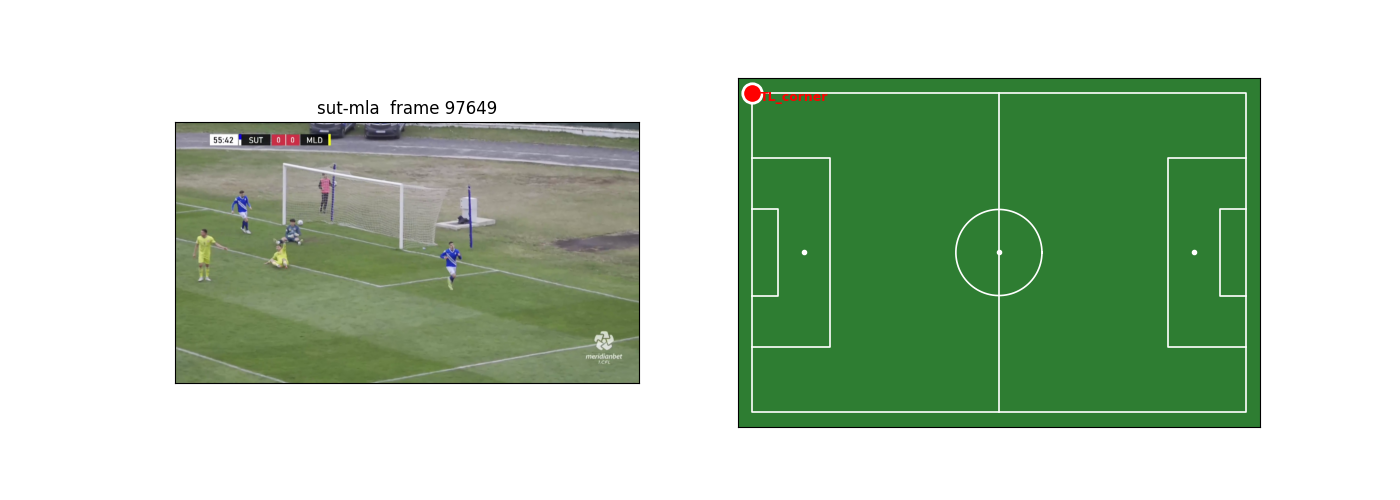

In [16]:
%matplotlib widget
from src.manual_calibration import (
    build_labeling_widget, calibration_path, load_calibration,
)

# state['idx'] is the demo-MP4 frame index from the labeling widget above.
# Override DEMO_IDX manually if you want to calibrate a specific frame.
DEMO_IDX  = state['idx']
ABS_FRAME = start_abs + DEMO_IDX

cap_src = cv2.VideoCapture(str(Config.MATCH_VIDEOS[MATCH]))
cap_src.set(cv2.CAP_PROP_POS_FRAMES, ABS_FRAME)
ok, src_frame = cap_src.read()
cap_src.release()
if not ok:
    raise RuntimeError(f'Could not read frame {ABS_FRAME} from source video')

print(f'Calibrating demo idx {DEMO_IDX} → source frame {ABS_FRAME}')
existing_path = calibration_path(MATCH, ABS_FRAME)
existing = load_calibration(existing_path) if existing_path.exists() else None

build_labeling_widget(MATCH, src_frame, ABS_FRAME, existing=existing)


### 5c · Compare pipeline vs ground truth

For every calibrated frame in `data/manual_calibration/{slug}_*.json`, runs
PnLCalib + refine once on the source frame and overlays the result against the
ground truth:

- **white** lines: current pipeline output
- **cyan** lines: manual ground truth
- **red dots**: clicked landmarks

Reports mean pixel error per frame at 7 reference world points (center spot,
halfway-line endpoints, PA outer corners). Lower is better. Comparison images
land in `output/demo/diag/gt_compare/`.

In [ ]:
%matplotlib inline
from src.manual_calibration import calibration_dir, load_calibration

GT_DIR = Path('../output/demo/diag/gt_compare')
GT_DIR.mkdir(parents=True, exist_ok=True)

seed_paths = sorted(calibration_dir().glob(f'{MATCH}_frame_*.json'))
print(f'Found {len(seed_paths)} calibrated frame(s) for {MATCH}')

cap_cmp = cv2.VideoCapture(str(Config.MATCH_VIDEOS[MATCH]))
fw_cmp  = int(cap_cmp.get(cv2.CAP_PROP_FRAME_WIDTH))
fhv_cmp = int(cap_cmp.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Reference world points used to score pipeline-vs-GT pixel deviation.
TEST_WORLD_PTS = [
    (52.5, 34.0,  0.0),
    (52.5,  0.0,  0.0), (52.5, 68.0,  0.0),
    (16.5, 13.84, 0.0), (16.5, 54.16, 0.0),
    (88.5, 13.84, 0.0), (88.5, 54.16, 0.0),
]


def _project(P, w):
    v = P @ np.array([w[0] - 52.5, w[1] - 34.0, w[2], 1])
    return None if v[2] <= 0 else (v[0] / v[2], v[1] / v[2])


errors = []
for sp in seed_paths:
    cal = load_calibration(sp)
    if cal.P_pnlcalib_convention is None:
        continue
    P_gt = np.array(cal.P_pnlcalib_convention, dtype=np.float64)
    abs_f = cal.frame_number

    cap_cmp.set(cv2.CAP_PROP_POS_FRAMES, abs_f)
    ok, frm = cap_cmp.read()
    if not ok:
        continue

    # Per-frame pipeline answer — no flow / smoother, just PnLCalib + refine.
    P_pred, status = predict_one_frame(frm, pnl_models, fw_cmp, fhv_cmp)
    if P_pred is not None:
        P_pred = refine_projection_to_lines(P_pred, frm)

    deltas = []
    if P_pred is not None:
        for w in TEST_WORLD_PTS:
            a = _project(P_pred, w)
            b = _project(P_gt, w)
            if a and b:
                deltas.append(float(np.hypot(a[0] - b[0], a[1] - b[1])))
    pix_err = float(np.mean(deltas)) if deltas else float('nan')
    errors.append((abs_f, pix_err, status, P_pred is not None))

    vis = frm.copy()
    if P_pred is not None:
        project_lines(vis, P_pred, color=(255, 255, 255), thickness=2)
    project_lines(vis, P_gt, color=(255, 200, 0), thickness=2)
    for _name, _pit, (px, py) in cal.correspondences:
        cv2.circle(vis, (int(px), int(py)), 6, (0, 0, 255), -1)
        cv2.circle(vis, (int(px), int(py)), 6, (255, 255, 255), 1)
    cv2.putText(vis, f'frame={abs_f}  pix_err={pix_err:.1f}  {status}',
                (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)
    cv2.imwrite(str(GT_DIR / f'cmp_{abs_f:07d}.jpg'), vis)

cap_cmp.release()

print()
print(f'{"frame":>9} {"px_err":>8} {"ok":>3}  status')
for f, e, s, ok in sorted(errors):
    print(f'{f:>9d} {e:>8.1f} {"Y" if ok else "N":>3}  {s}')

valid = [e for _f, e, _s, ok in errors if ok and not np.isnan(e)]
if valid:
    print(f'\nMean pixel error across {len(valid)} GT frames: {np.mean(valid):.1f} px')
print(f'Wrote comparison images to {GT_DIR}')
